In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits  # MNIST-like 8x8 version
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier




In [2]:
# Load dataset
digits = load_digits()
X, y = digits.data, digits.target



In [ ]:
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

##  Train All Models & Collect Metrics

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision (macro)": report["macro avg"]["precision"],
        "Recall (macro)": report["macro avg"]["recall"],
        "F1-score (macro)": report["macro avg"]["f1-score"]
    })

    # Store misclassified images for error analysis
    if name == "Logistic Regression":  # Only once
        misclassified_indices = np.where(y_test != y_pred)[0][:10]
        misclassified_samples = [(X_test[i], y_test[i], y_pred[i]) for i in misclassified_indices]


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:46:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 ## Display Results in a Table

In [7]:
# Create a performance DataFrame
performance_df = pd.DataFrame(results)
print(performance_df.round(3))


                 Model  Accuracy  Precision (macro)  Recall (macro)  \
0  Logistic Regression     0.980              0.980           0.979   
1                  SVM     0.981              0.982           0.981   
2        Decision Tree     0.857              0.860           0.857   
3        Random Forest     0.969              0.969           0.968   
4              XGBoost     0.948              0.948           0.948   

   F1-score (macro)  
0             0.980  
1             0.981  
2             0.858  
3             0.968  
4             0.948  


##  Bar Plot Comparison with Seaborn

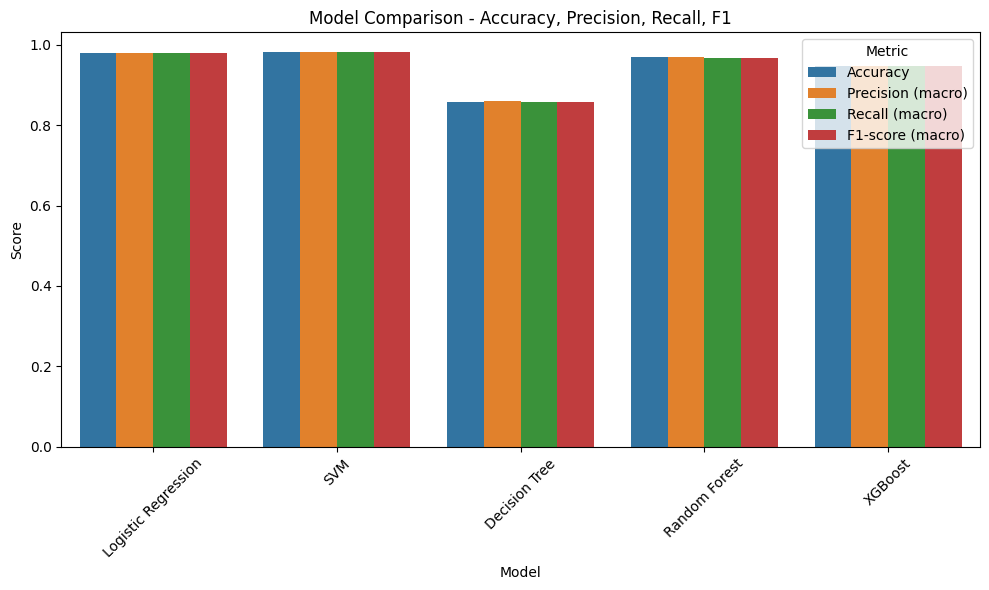

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
            x="Model", y="Score", hue="Metric")
plt.title("Model Comparison - Accuracy, Precision, Recall, F1")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Error Analysis (Plot Misclassified Images)

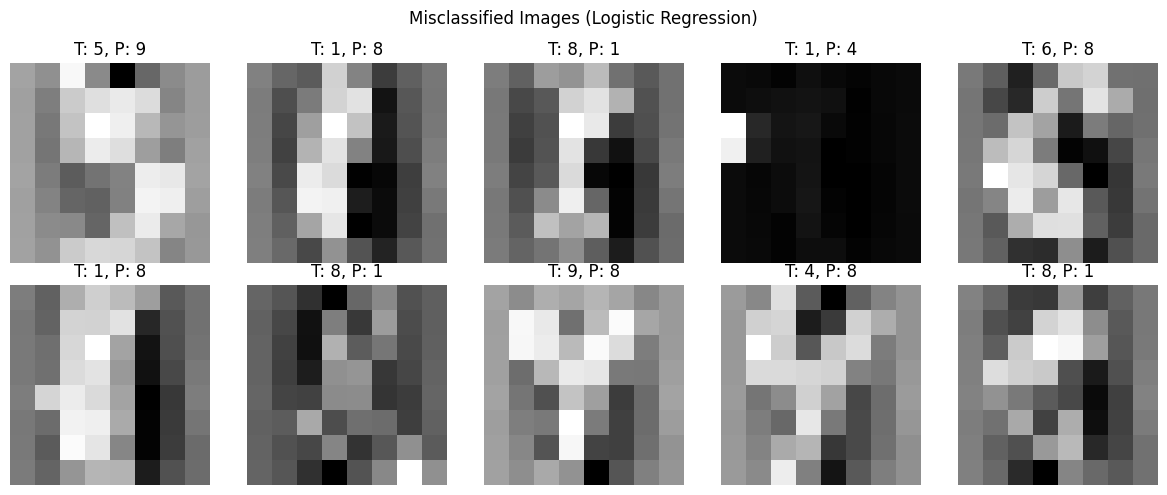

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Misclassified Images (Logistic Regression)")

for i, (img, true_label, pred_label) in enumerate(misclassified_samples):
    ax = axes[i//5, i%5]
    ax.imshow(img.reshape(8, 8), cmap="gray")
    ax.set_title(f"T: {true_label}, P: {pred_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Confusion Matrix 

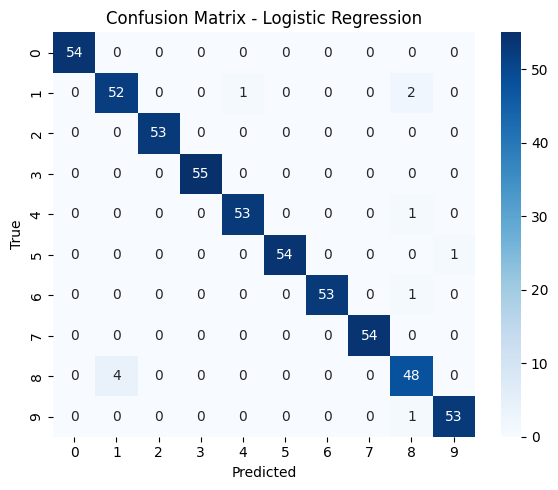

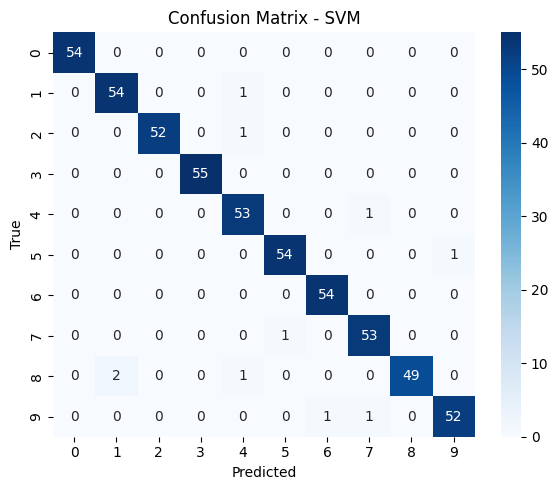

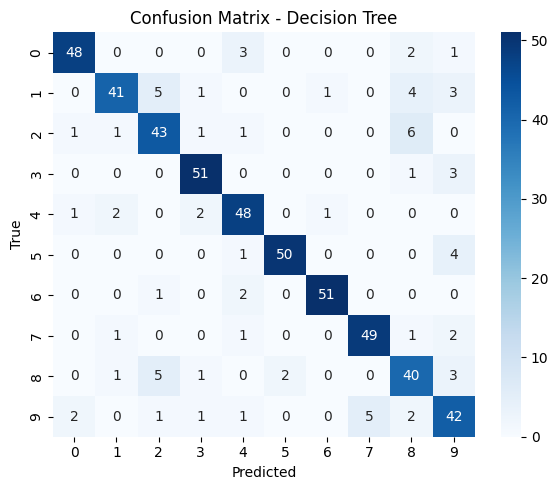

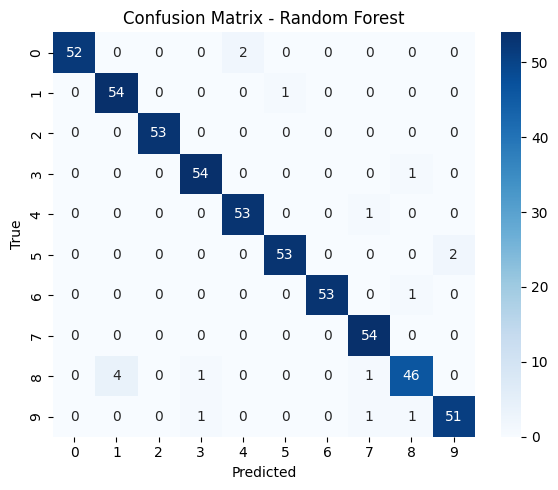

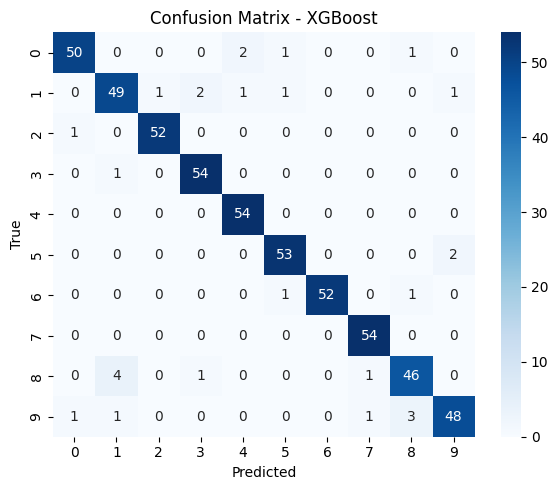

In [10]:
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


 ## Interactive Plot with Plotly

In [13]:
import plotly.express as px

fig = px.bar(performance_df.melt(id_vars='Model'),
             x='Model', y='value', color='variable',
             title="Model Comparison - Interactive View",
             labels={'value': 'Score', 'variable': 'Metric'})
fig.show()
